In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load feature dataset
features = np.load("../data/features.npy")
labels = np.load("../data/labels.npy")

# Load trained Random Forest model
model = joblib.load("../models/random_forest_model.pkl")

print("Model loaded successfully!")

print("\nFeatures Shape:", features.shape)
print("Labels Shape:", labels.shape)

print("\nClass Distribution:")
print("Normal:", np.sum(labels == 0))
print("Seizure:", np.sum(labels == 1))

Model loaded successfully!

Features Shape: (900, 8)
Labels Shape: (900,)

Class Distribution:
Normal: 890
Seizure: 10


In [3]:
# Recreate the stratified train-test split

X_train, X_test, y_train, y_test = train_test_split(
    features,
    labels,
    test_size=0.20,
    random_state=42,
    stratify=labels
)

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)

print("Training Labels Shape:", y_train.shape)
print("Testing Labels Shape:", y_test.shape)

print("\nTraining Class Distribution:")
print(np.unique(y_train, return_counts=True))

print("\nTesting Class Distribution:")
print(np.unique(y_test, return_counts=True))

Training Features Shape: (720, 8)
Testing Features Shape: (180, 8)
Training Labels Shape: (720,)
Testing Labels Shape: (180,)

Training Class Distribution:
(array([0, 1]), array([712,   8]))

Testing Class Distribution:
(array([0, 1]), array([178,   2]))


In [4]:
# Baseline prediction using default threshold = 0.5

y_pred_baseline = model.predict(X_test)

print("Baseline predictions generated successfully!")

print("\nActual Class Distribution:")
print(np.unique(y_test, return_counts=True))

print("\nPredicted Class Distribution:")
print(np.unique(y_pred_baseline, return_counts=True))

Baseline predictions generated successfully!

Actual Class Distribution:
(array([0, 1]), array([178,   2]))

Predicted Class Distribution:
(array([0]), array([180]))


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [5]:
# Baseline confusion matrix

cm_baseline = confusion_matrix(
    y_test,
    y_pred_baseline
)

print("Baseline Confusion Matrix:")
print(cm_baseline)

print("\nBaseline Classification Report:")

print(
    classification_report(
        y_test,
        y_pred_baseline,
        target_names=["Normal", "Seizure"],
        zero_division=0
    )
)

Baseline Confusion Matrix:
[[178   0]
 [  2   0]]

Baseline Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99       178
     Seizure       0.00      0.00      0.00         2

    accuracy                           0.99       180
   macro avg       0.49      0.50      0.50       180
weighted avg       0.98      0.99      0.98       180



In [6]:
# Calculate baseline metrics

baseline_accuracy = accuracy_score(
    y_test,
    y_pred_baseline
)

baseline_precision = precision_score(
    y_test,
    y_pred_baseline,
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    y_pred_baseline,
    zero_division=0
)

baseline_f1 = f1_score(
    y_test,
    y_pred_baseline,
    zero_division=0
)

tn, fp, fn, tp = cm_baseline.ravel()

baseline_sensitivity = tp / (tp + fn)

baseline_specificity = tn / (tn + fp)

baseline_balanced_accuracy = balanced_accuracy_score(
    y_test,
    y_pred_baseline
)

print("Baseline Results")
print("--------------------------")
print("Accuracy:", baseline_accuracy)
print("Precision:", baseline_precision)
print("Sensitivity:", baseline_sensitivity)
print("Specificity:", baseline_specificity)
print("F1-Score:", baseline_f1)
print("Balanced Accuracy:", baseline_balanced_accuracy)

Baseline Results
--------------------------
Accuracy: 0.9888888888888889
Precision: 0.0
Sensitivity: 0.0
Specificity: 1.0
F1-Score: 0.0
Balanced Accuracy: 0.5


In [7]:
# Generate seizure probabilities

y_prob = model.predict_proba(X_test)[:, 1]

# Selected threshold from our experiment
best_threshold = 0.05

# Generate threshold-adjusted predictions
y_pred_threshold = (
    y_prob >= best_threshold
).astype(int)

print("Threshold-adjusted predictions generated successfully!")
print("Selected Threshold:", best_threshold)

print("\nPredicted Class Distribution:")
print(np.unique(y_pred_threshold, return_counts=True))

Threshold-adjusted predictions generated successfully!
Selected Threshold: 0.05

Predicted Class Distribution:
(array([0, 1]), array([157,  23]))


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [8]:
# Threshold-adjusted confusion matrix

cm_threshold = confusion_matrix(
    y_test,
    y_pred_threshold
)

print("Threshold-Adjusted Confusion Matrix:")
print(cm_threshold)

print("\nThreshold-Adjusted Classification Report:")

print(
    classification_report(
        y_test,
        y_pred_threshold,
        target_names=["Normal", "Seizure"],
        zero_division=0
    )
)

Threshold-Adjusted Confusion Matrix:
[[156  22]
 [  1   1]]

Threshold-Adjusted Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.88      0.93       178
     Seizure       0.04      0.50      0.08         2

    accuracy                           0.87       180
   macro avg       0.52      0.69      0.51       180
weighted avg       0.98      0.87      0.92       180



In [9]:
# Calculate threshold-adjusted metrics

threshold_accuracy = accuracy_score(
    y_test,
    y_pred_threshold
)

threshold_precision = precision_score(
    y_test,
    y_pred_threshold,
    zero_division=0
)

threshold_recall = recall_score(
    y_test,
    y_pred_threshold,
    zero_division=0
)

threshold_f1 = f1_score(
    y_test,
    y_pred_threshold,
    zero_division=0
)

tn, fp, fn, tp = cm_threshold.ravel()

threshold_sensitivity = tp / (tp + fn)

threshold_specificity = tn / (tn + fp)

threshold_balanced_accuracy = balanced_accuracy_score(
    y_test,
    y_pred_threshold
)

print("Threshold-Adjusted Results")
print("--------------------------")
print("Accuracy:", threshold_accuracy)
print("Precision:", threshold_precision)
print("Sensitivity:", threshold_sensitivity)
print("Specificity:", threshold_specificity)
print("F1-Score:", threshold_f1)
print("Balanced Accuracy:", threshold_balanced_accuracy)

Threshold-Adjusted Results
--------------------------
Accuracy: 0.8722222222222222
Precision: 0.043478260869565216
Sensitivity: 0.5
Specificity: 0.8764044943820225
F1-Score: 0.08
Balanced Accuracy: 0.6882022471910112


In [10]:
# Compare baseline and threshold-adjusted models

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Sensitivity",
        "Specificity",
        "F1-Score",
        "Balanced Accuracy"
    ],
    
    "Baseline (0.50)": [
        baseline_accuracy,
        baseline_precision,
        baseline_sensitivity,
        baseline_specificity,
        baseline_f1,
        baseline_balanced_accuracy
    ],
    
    "Threshold Adjusted (0.05)": [
        threshold_accuracy,
        threshold_precision,
        threshold_sensitivity,
        threshold_specificity,
        threshold_f1,
        threshold_balanced_accuracy
    ]
})

comparison

,Metric,Baseline (0.50),Threshold Adjusted (0.05)
0,Accuracy,0.988889,0.872222
1,Precision,0.000000,0.043478
2,Sensitivity,0.000000,0.500000
3,Specificity,1.000000,0.876404
4,F1-Score,0.000000,0.080000
5,Balanced Accuracy,0.500000,0.688202


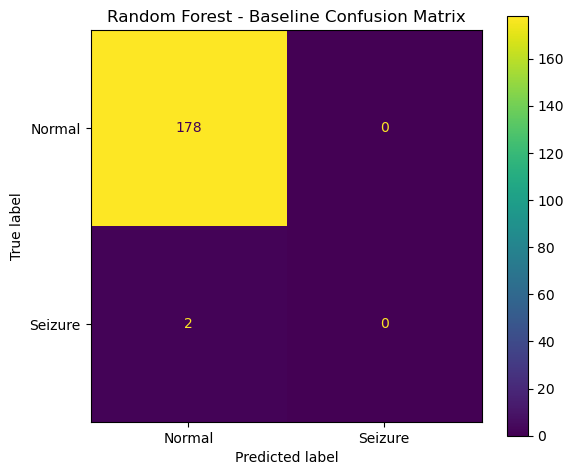

In [11]:
# Plot baseline confusion matrix

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay(
    confusion_matrix=cm_baseline,
    display_labels=["Normal", "Seizure"]
).plot(ax=ax)

plt.title("Random Forest - Baseline Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "../images/random_forest_baseline_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

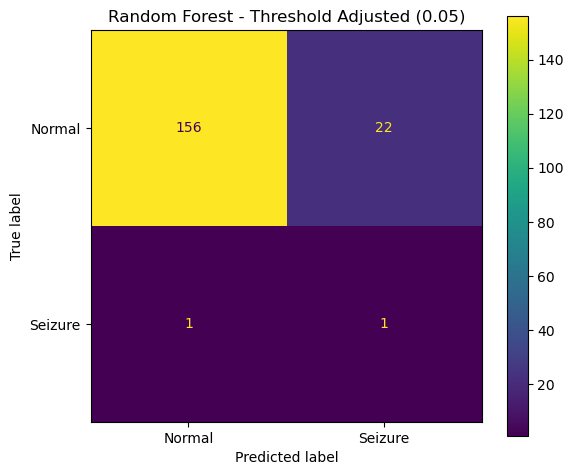

In [12]:
# Plot threshold-adjusted confusion matrix

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay(
    confusion_matrix=cm_threshold,
    display_labels=["Normal", "Seizure"]
).plot(ax=ax)

plt.title(
    "Random Forest - Threshold Adjusted (0.05)"
)

plt.tight_layout()

plt.savefig(
    "../images/random_forest_threshold_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
# FINAL AUTHORITATIVE MODEL EVALUATION

import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score
)

# Load the exact dataset
features = np.load("../data/features.npy")
labels = np.load("../data/labels.npy")

# Load the exact trained model
model = joblib.load("../models/random_forest_model.pkl")

# Create one fixed, stratified split
X_train, X_test, y_train, y_test = train_test_split(
    features,
    labels,
    test_size=0.20,
    random_state=42,
    stratify=labels
)

# Get probability predictions
y_prob = model.predict_proba(X_test)[:, 1]

# Default threshold
threshold = 0.50

y_pred = (y_prob >= threshold).astype(int)

# Metrics
cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
specificity = tn / (tn + fp)
balanced_acc = balanced_accuracy_score(y_test, y_pred)

print("FINAL AUTHORITATIVE EVALUATION")
print("=" * 40)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Normal", "Seizure"],
        zero_division=0
    )
)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Sensitivity:", recall)
print("Specificity:", specificity)
print("F1-Score:", f1)
print("Balanced Accuracy:", balanced_acc)

print("\nTest Class Distribution:")
print(np.unique(y_test, return_counts=True))

print("\nPredicted Class Distribution:")
print(np.unique(y_pred, return_counts=True))

print("\nTest Seizure Probabilities:")
print(y_prob[y_test == 1])

FINAL AUTHORITATIVE EVALUATION

Confusion Matrix:
[[178   0]
 [  2   0]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99       178
     Seizure       0.00      0.00      0.00         2

    accuracy                           0.99       180
   macro avg       0.49      0.50      0.50       180
weighted avg       0.98      0.99      0.98       180

Accuracy: 0.9888888888888889
Precision: 0.0
Sensitivity: 0.0
Specificity: 1.0
F1-Score: 0.0
Balanced Accuracy: 0.5

Test Class Distribution:
(array([0, 1]), array([178,   2]))

Predicted Class Distribution:
(array([0]), array([180]))

Test Seizure Probabilities:
[0.06 0.  ]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [14]:
# FINAL THRESHOLD ANALYSIS

threshold = 0.05

y_pred_threshold = (
    y_prob >= threshold
).astype(int)

cm_threshold = confusion_matrix(
    y_test,
    y_pred_threshold
)

tn, fp, fn, tp = cm_threshold.ravel()

sensitivity_threshold = tp / (tp + fn)

specificity_threshold = tn / (tn + fp)

print("FINAL THRESHOLD ANALYSIS")
print("=" * 40)

print("Threshold:", threshold)

print("\nConfusion Matrix:")
print(cm_threshold)

print("\nSensitivity:", sensitivity_threshold)

print("Specificity:", specificity_threshold)

print("\nPredicted Class Distribution:")
print(
    np.unique(
        y_pred_threshold,
        return_counts=True
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_threshold,
        target_names=[
            "Normal",
            "Seizure"
        ],
        zero_division=0
    )
)

FINAL THRESHOLD ANALYSIS
Threshold: 0.05

Confusion Matrix:
[[156  22]
 [  1   1]]

Sensitivity: 0.5
Specificity: 0.8764044943820225

Predicted Class Distribution:
(array([0, 1]), array([157,  23]))

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.88      0.93       178
     Seizure       0.04      0.50      0.08         2

    accuracy                           0.87       180
   macro avg       0.52      0.69      0.51       180
weighted avg       0.98      0.87      0.92       180

